# Examen Sistemas de Aprendizaje Automático






*  En este examen hay una parte de laboratorio y un problema.
*  Dentro del laboratorio vamos a tener distintas preguntas.
*  Se deberá entregar el fichero en formato ipynb y pdf.
*  En nombre del fichero debe de tener el siguiente formato: NOMBRE_APE1_APE2
*  Se puede utilizar el buscador Google, prácticas anteriores y apuntes de la asignatura.
*  Se valorará la originalidad de los experimentos, haciendose mucho hincapié en la calidad de la conclusión de los mismos.
*  Se tendrá en cuenta positivamente aquellos modelos con mejor desempeño.
*  Duración máxima 2 horas.


## **Laboratorio**

Hemos escogido para este laboratorio el dataset fashion-mnist, el motivo es que
es un problema sencillo de entrenar por lo que nuestros modelos deben de entrenarse de una forma rápida.
Lee atentamente los enunciados, en cada pregunta te aparecerá lo que vale.

Descargamos dataset, visualizamos y reshape.

In [23]:
import tensorflow as tf

import numpy as np
import matplotlib.pyplot as plt
from keras.callbacks import EarlyStopping


# Load the fashion-mnist pre-shuffled train data and test data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print("x_train shape:", x_train.shape, "y_train shape:", y_train.shape)

x_train shape: (60000, 28, 28) y_train shape: (60000,)


x_train shape: (60000, 28, 28) y_train shape: (60000,)
60000 train set
10000 test set
y = 2 Pullover


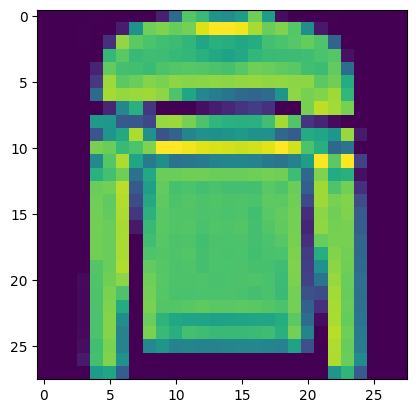

In [24]:
# Print training set shape - note there are 60,000 training data of image size of 28x28, 60,000 train labels)
print("x_train shape:", x_train.shape, "y_train shape:", y_train.shape)

# Print the number of training and test datasets
print(x_train.shape[0], 'train set')
print(x_test.shape[0], 'test set')

# Define the text labels
fashion_mnist_labels = ["T-shirt/top",  # index 0
                        "Trouser",      # index 1
                        "Pullover",     # index 2
                        "Dress",        # index 3
                        "Coat",         # index 4
                        "Sandal",       # index 5
                        "Shirt",        # index 6
                        "Sneaker",      # index 7
                        "Bag",          # index 8
                        "Ankle boot"]   # index 9

# Image index, you can pick any number between 0 and 59,999
img_index = 5
# y_train contains the lables, ranging from 0 to 9
label_index = y_train[img_index]
# Print the label, for example 2 Pullover
print ("y = " + str(label_index) + " " +(fashion_mnist_labels[label_index]))
# # Show one of the images from the training dataset
plt.imshow(x_train[img_index])

In [25]:
w, h = 28, 28
x_train = x_train.reshape(x_train.shape[0], w, h, 1)
x_test = x_test.reshape(x_test.shape[0], w, h, 1)

x_train.shape

(60000, 28, 28, 1)

### **Preparación de datos**





#### 1) ¿ En este dataset existe alguna clase de sesgo ? En caso de qué lo hubiera realiza las acciones oportunas para solucionarlo. (0.5 puntos)

In [26]:
import numpy as np

# Contamos el número de ocurrencias por cada clase en el conjunto de entrenamiento
clases, conteos = np.unique(y_train, return_counts=True)

print("Distribución de clases en el conjunto de entrenamiento:")
for clase, conteo in zip(clases, conteos):
    print(f"{fashion_mnist_labels[clase]}: {conteo} muestras")

Distribución de clases en el conjunto de entrenamiento:
T-shirt/top: 6000 muestras
Trouser: 6000 muestras
Pullover: 6000 muestras
Dress: 6000 muestras
Coat: 6000 muestras
Sandal: 6000 muestras
Shirt: 6000 muestras
Sneaker: 6000 muestras
Bag: 6000 muestras
Ankle boot: 6000 muestras


In [27]:
# Normalización

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f"Rango de valores x_train normalizado: Min {np.min(x_train)} - Max {np.max(x_train)}")

Rango de valores x_train normalizado: Min 0.0 - Max 1.0


### **Experimento 1**

#### 2) Elige el tipo de red neuronal óptimo visto en esta asignatura para este tipo de problemas, crea una arquitectura capaz de superar al **80 %** en el val_acurracy, no se puede utilizar el optimizador SGD (1.5 puntos)

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# 1. Definición de la arquitectura CNN
model_cnn = Sequential([
    # Primera capa convolucional y max pooling
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    # Segunda capa convolucional y max pooling para extraer características más complejas
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Aplanamos los mapas de características para conectarlos a la red densa
    Flatten(),

    # Capa densa con Dropout para evitar sobreajuste (overfitting)
    Dense(128, activation='relu'),
    Dropout(0.3),

    # Capa de salida con 10 neuronas (una por clase) y activación softmax
    Dense(10, activation='softmax')
])

# 2. Compilación del modelo
# Usamos 'sparse_categorical_crossentropy' porque las etiquetas (y_train) son enteros (0-9)
model_cnn.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# 3. Entrenamiento del modelo
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_cnn = model_cnn.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2, # Usamos el 20% del train para validación y medir el val_accuracy
    callbacks=[early_stop]
)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7957 - loss: 0.5638 - val_accuracy: 0.8629 - val_loss: 0.3802
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8676 - loss: 0.3649 - val_accuracy: 0.8827 - val_loss: 0.3167
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8857 - loss: 0.3145 - val_accuracy: 0.8923 - val_loss: 0.2881
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8963 - loss: 0.2835 - val_accuracy: 0.8994 - val_loss: 0.2689
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9068 - loss: 0.2583 - val_accuracy: 0.9092 - val_loss: 0.2487
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9112 - loss: 0.2404 - val_accuracy: 0.9036 - val_loss: 0.2574
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9176 - loss: 0.2218 - val_accuracy: 0.9102 - val_loss: 0.2399
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9227 - loss: 0.2064 - val_accuracy: 0.

#### 3) Durante este laboratorio vamos a realizar una serie de experimentos, por qué necesitamos que realices una estructura de tabla de experimentación y de comparativa por epochs de val_acurracy en la visualización. (0.5 puntos)

Funciones para gráficas.

In [29]:
# Definición de funciones que permitirán la visualización de las graficas de entrenamiento
def plot_acc(history, title="Model Accuracy"):
    """Imprime una gráfica mostrando la accuracy por epoch obtenida en un entrenamiento"""
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(title)
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Entrenamiento', 'Validación'], loc='upper left')
    plt.show()

def plot_loss(history, title="Model Loss"):
    """Imprime una gráfica mostrando la pérdida por epoch obtenida en un entrenamiento"""
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(title)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Entrenamiento', 'Validación'], loc='upper right')
    plt.show()

def plot_compare_losses(history1, history2, name1="Red 1",
                        name2="Red 2", title="Graph title"):
    """Compara losses de dos entrenamientos con nombres name1 y name2"""
    plt.plot(history1.history['loss'], color="green")
    plt.plot(history1.history['val_loss'], '--', color="green")
    plt.plot(history2.history['loss'], color="blue")
    plt.plot(history2.history['val_loss'], '--', color="blue")
    plt.title(title)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Entrenamiento ' + name1, 'Validación ' + name1,
                'Entrenamiento ' + name2, 'Validación ' + name2],
               loc='upper right')
    plt.show()

def plot_compare_accs(history1, history2, name1="Red 1",
                      name2="Red 2", title="Graph title"):
    """Compara accuracies de dos entrenamientos con nombres name1 y name2"""
    plt.plot(history1.history['accuracy'], color="green")
    plt.plot(history1.history['val_accuracy'], '--', color="green")
    plt.plot(history2.history['accuracy'], color="blue")
    plt.plot(history2.history['val_accuracy'], '--', color="blue")
    plt.title(title)
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train ' + name1, 'Val ' + name1,
                'Train ' + name2, 'Val ' + name2],
               loc='lower right')
    plt.show()

Tabla de experimentación.

In [30]:
from prettytable import PrettyTable

def registrar_experimento(tabla, history_obj, nombre_exp, descripcion):
    """
    Extrae los mejores resultados de un objeto history de Keras,
    los añade a la tabla y la imprime.
    """
    # 1. Encontrar el índice de la época con el mejor validation accuracy
    # Usamos .history['val_accuracy'] que es la lista de métricas por época
    indice_mejor_val_acc = np.argmax(history_obj.history['val_accuracy'])

    # 2. Extraer los valores de esa época específica
    acc = history_obj.history['accuracy'][indice_mejor_val_acc]
    loss = history_obj.history['loss'][indice_mejor_val_acc]
    val_acc = history_obj.history['val_accuracy'][indice_mejor_val_acc]
    val_loss = history_obj.history['val_loss'][indice_mejor_val_acc]

    # 3. Añadir la fila a la tabla redondeando a 4 decimales
    tabla.add_row([
        nombre_exp,
        descripcion,
        f"{acc:.4f}",
        f"{loss:.4f}",
        f"{val_acc:.4f}",
        f"{val_loss:.4f}"
    ])

    # 4. Imprimir la tabla actualizada
    print(tabla)


# Inicializas la tabla
mi_tabla = PrettyTable(["Experimento", "Descripción", "Accuracy", "Loss", "Val_Accuracy", "Val_Loss"])

# 1. Registrar el Experimento 1 en la tabla
registrar_experimento(mi_tabla,
                      history_cnn,
                      "Experimento 1",
                      "CNN Base (2 Conv2D + MaxPool), Dropout 0.3, Adam")

+---------------+--------------------------------------------------+----------+--------+--------------+----------+
|  Experimento  |                   Descripción                    | Accuracy |  Loss  | Val_Accuracy | Val_Loss |
+---------------+--------------------------------------------------+----------+--------+--------------+----------+
| Experimento 1 | CNN Base (2 Conv2D + MaxPool), Dropout 0.3, Adam |  0.9408  | 0.1552 |    0.9168    |  0.2495  |
+---------------+--------------------------------------------------+----------+--------+--------------+----------+


#### 4) Justifica el motivo de la elección de este tipo de red neuronal artificial. (1 punto)

La elección de una Red Neuronal Convolucional (CNN) frente a una red tradicional (como un Perceptrón Multicapa o Red Densa) para el dataset Fashion-MNIST se fundamenta en su capacidad superior para procesar datos con topología de cuadrícula, como son las imágenes en 2D.

Los motivos principales de esta elección son:

* **Preservación de la estructura espacial:** Si usáramos una red densa tradicional, tendríamos que aplanar la imagen de 28x28 en un vector unidimensional de 784 píxeles desde el principio, perdiendo toda la información sobre la proximidad física entre los píxeles. Las CNNs operan directamente sobre matrices bidimensionales, manteniendo el contexto local que es vital para identificar la forma de las prendas de ropa.
* **Extracción jerárquica de características:** Las primeras capas convolucionales actúan como detectores de características de bajo nivel (detectando bordes, líneas y esquinas en una camiseta o pantalón). A medida que avanzamos en la red, las capas combinan estos elementos para aprender patrones de alto nivel (como el asa de un bolso o el cuello de un abrigo).
* **Invarianza a la traslación:** Gracias a que los filtros convolucionales se deslizan por toda la imagen (pesos compartidos) y al uso de las capas de *Max-Pooling*, la red es capaz de reconocer un patrón independientemente de en qué parte exacta de la imagen se encuentre. No importa si un zapato está ligeramente desplazado a la izquierda o a la derecha, la red lo detectará igual.
* **Eficiencia paramétrica y prevención de sobreajuste:** En una red densa, cada neurona se conecta a todos los píxeles de entrada, lo que dispara el número de parámetros a entrenar y aumenta drásticamente el riesgo de sobreajuste (overfitting). Las CNNs comparten los pesos de un mismo filtro por toda la imagen, lo que reduce drásticamente los parámetros matemáticos, haciendo que el entrenamiento sea más rápido y el modelo generalice mejor con datos no vistos.


### **Experimento 2**

#### 5) Vamos a realizar un experimento aplicando una técnica de regularización denominada Dropout, en caso de que la hayas utilizado en el modelo anterior utiliza otro valor de Dropout. (1 punto)

In [31]:
# Definición de la arquitectura CNN con un nuevo valor de Dropout (0.5)
model_cnn_drop = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),

    # Capa densa con un Dropout más agresivo
    Dense(128, activation='relu'),
    Dropout(0.5), # Cambiamos de 0.3 a 0.5

    Dense(10, activation='softmax')
])

# Compilación
model_cnn_drop.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

history_cnn_drop = model_cnn_drop.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7653 - loss: 0.6473 - val_accuracy: 0.8545 - val_loss: 0.4051
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8470 - loss: 0.4262 - val_accuracy: 0.8793 - val_loss: 0.3367
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8683 - loss: 0.3650 - val_accuracy: 0.8828 - val_loss: 0.3122
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8810 - loss: 0.3310 - val_accuracy: 0.8909 - val_loss: 0.2946
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8876 - loss: 0.3072 - val_accuracy: 0.9012 - val_loss: 0.2751


#### 6) Mediante tabla y gráfica comparalo con el mejor modelo anterior, realiza una conclusión de experimento. (1 punto)

In [32]:
# 1. Añadimos el nuevo experimento a la tabla
registrar_experimento(mi_tabla,
                      history_cnn_drop,
                      "Experimento 2",
                      "CNN Base, Dropout 0.5, Adam")

+---------------+--------------------------------------------------+----------+--------+--------------+----------+
|  Experimento  |                   Descripción                    | Accuracy |  Loss  | Val_Accuracy | Val_Loss |
+---------------+--------------------------------------------------+----------+--------+--------------+----------+
| Experimento 1 | CNN Base (2 Conv2D + MaxPool), Dropout 0.3, Adam |  0.9408  | 0.1552 |    0.9168    |  0.2495  |
| Experimento 2 |           CNN Base, Dropout 0.5, Adam            |  0.8876  | 0.3072 |    0.9012    |  0.2751  |
+---------------+--------------------------------------------------+----------+--------+--------------+----------+


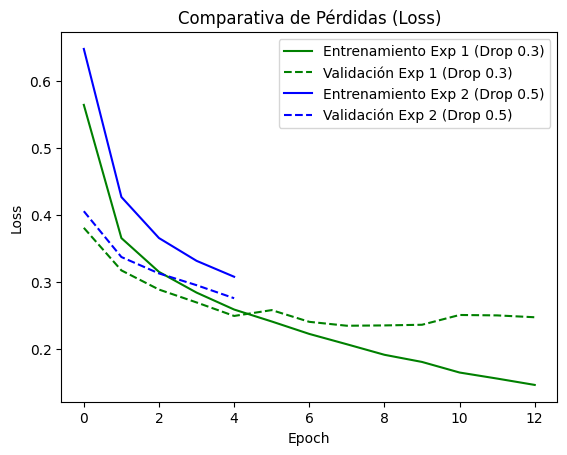

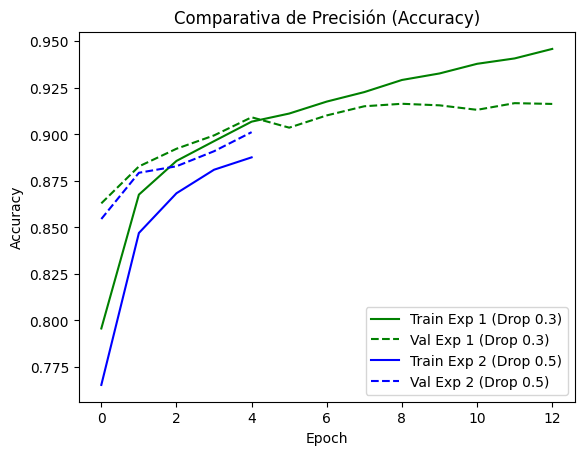

In [33]:
# 2. Visualizamos las gráficas comparativas usando tus funciones
plot_compare_losses(history_cnn, history_cnn_drop,
                    name1="Exp 1 (Drop 0.3)",
                    name2="Exp 2 (Drop 0.5)",
                    title="Comparativa de Pérdidas (Loss)")

plot_compare_accs(history_cnn, history_cnn_drop,
                  name1="Exp 1 (Drop 0.3)",
                  name2="Exp 2 (Drop 0.5)",
                  title="Comparativa de Precisión (Accuracy)")

### **Experimento 3**

#### 7) En este experimento se pretende modificar el optimizador a SGD (1 punto)

In [34]:
# Definición de la arquitectura CNN (igual al Exp 2)
model_cnn_sgd = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5), # Mantenemos el dropout del modelo anterior

    Dense(10, activation='softmax')
])

# Compilación usando el optimizador SGD clásico
model_cnn_sgd.compile(optimizer='sgd',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

history_cnn_sgd = model_cnn_sgd.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop] # Seguimos usando EarlyStopping
)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5130 - loss: 1.3551 - val_accuracy: 0.7279 - val_loss: 0.7657
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7050 - loss: 0.7913 - val_accuracy: 0.7352 - val_loss: 0.6582
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7426 - loss: 0.6880 - val_accuracy: 0.7860 - val_loss: 0.5608
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7659 - loss: 0.6286 - val_accuracy: 0.7982 - val_loss: 0.5377
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7811 - loss: 0.5893 - val_accuracy: 0.8148 - val_loss: 0.5110


#### 8) Mediante tabla y gráfica comparalo con el modelo anterior, realiza una conclusión de experimento. ¿ Qué gran desventaja tiene este optimizador con otros vistos en clase? (1 punto)

In [35]:
# 1. Añadimos el nuevo experimento a la tabla
registrar_experimento(mi_tabla,
                      history_cnn_sgd,
                      "Experimento 3",
                      "CNN Base, Dropout 0.5, SGD")

+---------------+--------------------------------------------------+----------+--------+--------------+----------+
|  Experimento  |                   Descripción                    | Accuracy |  Loss  | Val_Accuracy | Val_Loss |
+---------------+--------------------------------------------------+----------+--------+--------------+----------+
| Experimento 1 | CNN Base (2 Conv2D + MaxPool), Dropout 0.3, Adam |  0.9408  | 0.1552 |    0.9168    |  0.2495  |
| Experimento 2 |           CNN Base, Dropout 0.5, Adam            |  0.8876  | 0.3072 |    0.9012    |  0.2751  |
| Experimento 3 |            CNN Base, Dropout 0.5, SGD            |  0.7811  | 0.5893 |    0.8148    |  0.5110  |
+---------------+--------------------------------------------------+----------+--------+--------------+----------+


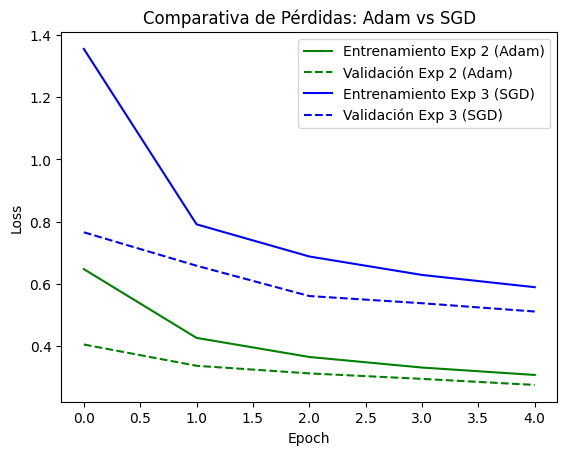

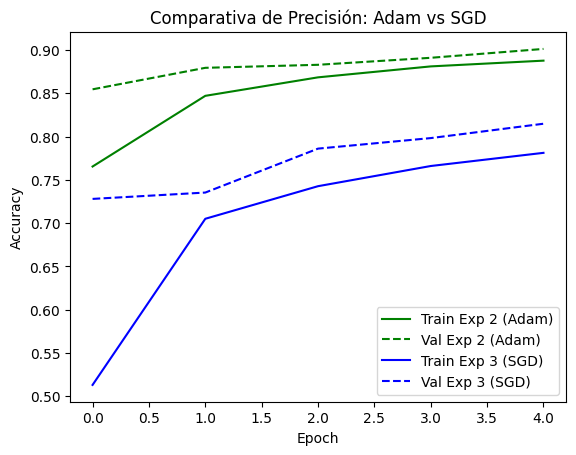

In [36]:
# 2. Visualizamos las gráficas comparativas usando tus funciones
plot_compare_losses(history_cnn_drop, history_cnn_sgd,
                    name1="Exp 2 (Adam)",
                    name2="Exp 3 (SGD)",
                    title="Comparativa de Pérdidas: Adam vs SGD")

plot_compare_accs(history_cnn_drop, history_cnn_sgd,
                  name1="Exp 2 (Adam)",
                  name2="Exp 3 (SGD)",
                  title="Comparativa de Precisión: Adam vs SGD")

### **Experimento 4**

####9) Utilizando el mejor modelo de los 3, visualiza mediante Visualkeras el modelo e indica los parámetros de un tipo de cada capa (1.5 punto)

Visualkeras te permite dibujar la arquitectura de una Red Neuronal Artificial.

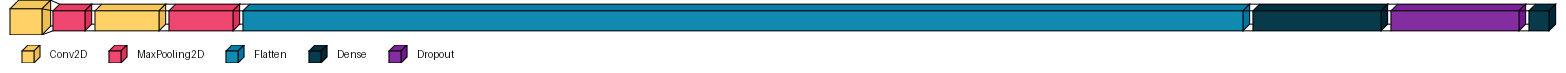

In [37]:
!pip install visualkeras

import visualkeras

# Parche de compatibilidad:
# Recorremos las capas del modelo y les inyectamos manualmente
# el atributo 'output_shape' que Visualkeras necesita para funcionar.
for layer in model_cnn.layers:
    if not hasattr(layer, 'output_shape'):
        layer.output_shape = tuple(layer.output.shape)

# Generamos la visualización en 3D de las capas con el Experimento 1 que fue el mejor accuracy
visualkeras.layered_view(model_cnn, legend=True, scale_xy=1, scale_z=1, max_z=1000)

## **Problema**

Nuestras redes neuronales son grafos de computación, Tensorflow por dentro está formado por estos, en la siguiente imagen tienes un grafo de computación.

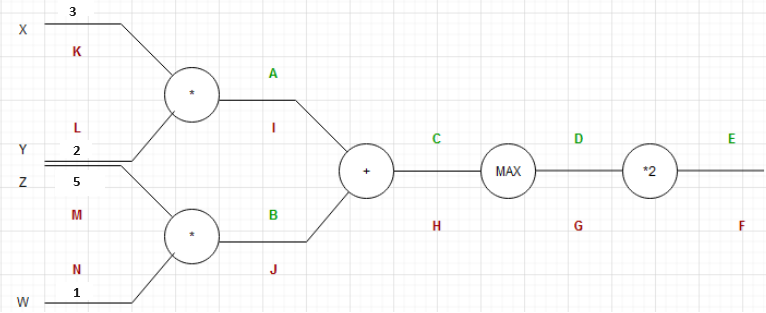

#### 10 ) A partir del grafo de computación aplica el algoritmo de backpropagation. (1 punto)



*  A: 6
*  B: 5
*  C: 11
*  D: 11
*  E: 22
*  F: 1
*  G: 2
*  H: 2
*  I: 2
*  J: 2
*  K: 4
*  L: 6
*  M: 2
*  N: 10